In [ ]:
# MODULE 8 — CUSTOMER SEGMENTATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans



# ============================================================
# 1. LOAD CLEANED DATASETS
# ============================================================


customers = pd.read_csv(
    "cleaned_saas_customers.csv"
)

subscriptions = pd.read_csv(
    "cleaned_saas_subscriptions.csv"
)

usage = pd.read_csv(
    "cleaned_saas_usage.csv"
)

tickets = pd.read_csv(
    "cleaned_saas_tickets.csv"
)

print("=" * 70)
print("MODULE 8 — CUSTOMER SEGMENTATION")
print("=" * 70)

print("\nDatasets loaded successfully.")


print("Customers:", customers.shape)
print("Subscriptions:", subscriptions.shape)
print("Usage:", usage.shape)
print("Tickets:", tickets.shape)


MODULE 8 — CUSTOMER SEGMENTATION

Datasets loaded successfully.
Customers: (420, 8)
Subscriptions: (437, 9)
Usage: (4640, 8)
Tickets: (1379, 7)


In [ ]:
# ============================================================
# 2. CONVERT NUMERIC COLUMNS
# ============================================================

subscriptions["MRR"] = pd.to_numeric(
    subscriptions["MRR"],
    errors="coerce"
)

subscriptions["Seats"] = pd.to_numeric(
    subscriptions["Seats"],
    errors="coerce"
)

usage["Logins"] = pd.to_numeric(
    usage["Logins"],
    errors="coerce"
)

usage["ActiveUsers"] = pd.to_numeric(
    usage["ActiveUsers"],
    errors="coerce"
)

usage["APICalls"] = pd.to_numeric(
    usage["APICalls"],
    errors="coerce"
)

usage["SessionMinutes"] = pd.to_numeric(
    usage["SessionMinutes"],
    errors="coerce"
)

tickets["ResolutionHours"] = pd.to_numeric(
    tickets["ResolutionHours"],
    errors="coerce"
)

tickets["SatisfactionScore"] = pd.to_numeric(
    tickets["SatisfactionScore"],
    errors="coerce"
)

print("Numeric conversion completed.")

Numeric conversion completed.


In [ ]:
# ============================================================
# 3. BUILD CUSTOMER-LEVEL FEATURES
# ============================================================

# ----------------------------
# Subscription features
# ----------------------------

subscription_features = (
    subscriptions
    .groupby("CustomerID")
    .agg(
        Total_MRR=("MRR", "sum"),
        Total_Seats=("Seats", "sum")
    )
    .reset_index()
)


# ----------------------------
# Usage features
# ----------------------------

usage_features = (
    usage
    .groupby("CustomerID")
    .agg(
        Total_Logins=("Logins", "sum"),
        Total_ActiveUsers=("ActiveUsers", "sum"),
        Total_APICalls=("APICalls", "sum"),
        Total_SessionMinutes=("SessionMinutes", "sum")
    )
    .reset_index()
)


# ----------------------------
# Ticket features
# ----------------------------

ticket_features = (
    tickets
    .groupby("CustomerID")
    .agg(
        Ticket_Count=("CustomerID", "count"),
        Avg_Satisfaction=("SatisfactionScore", "mean")
    )
    .reset_index()
)



In [ ]:
# ============================================================
# 4. MERGE CUSTOMER-LEVEL FEATURES
# ============================================================

customer_features = customers[
    ["CustomerID", "CompanyName"]
].copy()

customer_features = customer_features.merge(
    subscription_features,
    on="CustomerID",
    how="left"
)

customer_features = customer_features.merge(
    usage_features,
    on="CustomerID",
    how="left"
)

customer_features = customer_features.merge(
    ticket_features,
    on="CustomerID",
    how="left"
)

print("\nCustomer-level feature table:")
print(customer_features.head())

print("\nShape:", customer_features.shape)

#LEFT JOIN

#We start with the customer table because every customer should remain in the segmentation analysis,
#even if they have no recorded usage or tickets.

#For aggregated metrics such as usage or tickets,
#a missing value means there is no recorded activity, so we can treat those aggregated measures as zero.


Customer-level feature table:
  CustomerID               CompanyName  Total_MRR  Total_Seats  Total_Logins  \
0      C1001      Ishaan Joshi Systems     278.60          6.0         148.0   
1      C1002  Tara Sharma Technologies     246.76          4.0         217.0   
2      C1003          Zoya Das Systems     278.60          6.0         187.0   
3      C1004           Diya Joshi Labs      80.36          9.0          82.0   
4      C1005        Tara Joshi Systems     618.76          4.0         133.0   

   Total_ActiveUsers  Total_APICalls  Total_SessionMinutes  Ticket_Count  \
0               72.0         10276.0                2241.4           4.0   
1              134.0         15512.0                3021.1           4.0   
2              116.0         19771.0                4734.2           3.0   
3               42.0         14012.0                2530.0           NaN   
4               61.0         13232.0                2102.0           3.0   

   Avg_Satisfaction  
0        

In [ ]:

# ============================================================
# 5. HANDLE MISSING CUSTOMER ACTIVITY
# ============================================================

feature_columns = [
    "Total_MRR",
    "Total_Seats",
    "Total_Logins",
    "Total_ActiveUsers",
    "Total_APICalls",
    "Total_SessionMinutes",
    "Ticket_Count",
    "Avg_Satisfaction"
]

for col in feature_columns:
    customer_features[col] = customer_features[col].fillna(0)


print("\nCustomer-level features created.")

print(
    customer_features[
        ["CustomerID"] + feature_columns
    ].head()
)

print("\nMissing values in segmentation features:")
print(
    customer_features[feature_columns]
    .isna()
    .sum()
)



Customer-level features created.
  CustomerID  Total_MRR  Total_Seats  Total_Logins  Total_ActiveUsers  \
0      C1001     278.60          6.0         148.0               72.0   
1      C1002     246.76          4.0         217.0              134.0   
2      C1003     278.60          6.0         187.0              116.0   
3      C1004      80.36          9.0          82.0               42.0   
4      C1005     618.76          4.0         133.0               61.0   

   Total_APICalls  Total_SessionMinutes  Ticket_Count  Avg_Satisfaction  
0         10276.0                2241.4           4.0               6.5  
1         15512.0                3021.1           4.0               7.0  
2         19771.0                4734.2           3.0               3.0  
3         14012.0                2530.0           0.0               0.0  
4         13232.0                2102.0           3.0               6.0  

Missing values in segmentation features:
Total_MRR               0
Total_Seats    

In [ ]:
# ============================================================
# 6. SELECT FEATURES FOR CLUSTERING
# ============================================================

clustering_features = [
    "Total_MRR",
    "Total_Seats",
    "Total_Logins",
    "Total_ActiveUsers",
    "Total_APICalls",
    "Total_SessionMinutes",
    "Ticket_Count",
    "Avg_Satisfaction"
]

X = customer_features[
    clustering_features
].copy()

print("\nFeatures used for K-Means:")
print(clustering_features)

print("\nFeature matrix shape:", X.shape)


Features used for K-Means:
['Total_MRR', 'Total_Seats', 'Total_Logins', 'Total_ActiveUsers', 'Total_APICalls', 'Total_SessionMinutes', 'Ticket_Count', 'Avg_Satisfaction']

Feature matrix shape: (420, 8)


In [ ]:
# 7. SCALE FEATURES
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nFeatures scaled successfully.")
print("Scaled matrix shape:", X_scaled.shape)


Features scaled successfully.
Scaled matrix shape: (420, 8)


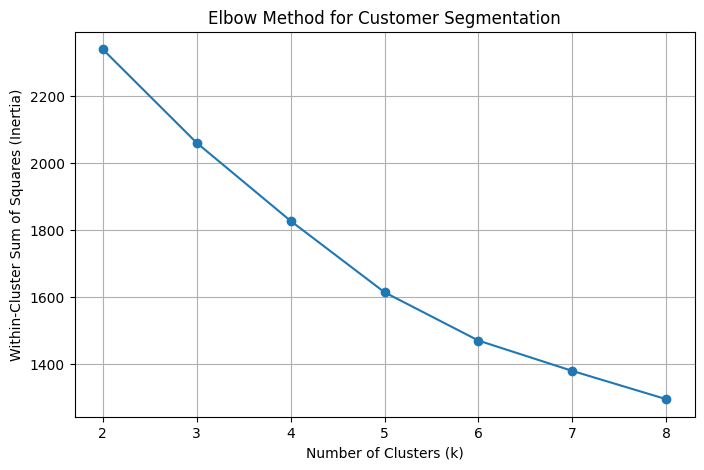


Elbow Method Results:
   k      Inertia
0  2  2338.917356
1  3  2060.074865
2  4  1827.401655
3  5  1614.619945
4  6  1470.620716
5  7  1380.166654
6  8  1295.898317


In [ ]:

# ============================================================
# 8. ELBOW METHOD
# ============================================================

inertia = []

k_values = range(2, 9)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(
        kmeans.inertia_
    )


# ============================================================
# 9. ELBOW PLOT
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia,
    marker="o"
)


plt.title("Elbow Method for Customer Segmentation")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()


# 10. DISPLAY ELBOW VALUES
# ============================================================

elbow_table = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertia
})

print("\nElbow Method Results:")
print(elbow_table)

#The Elbow Method indicated k = 4 because the reduction in inertia became substantially smaller after four clusters.
#Therefore, four clusters were selected as a practical balance between segmentation detail and model simplicity.



In [ ]:
# ============================================================
# 11. CHOOSE K
# ============================================================

# Based on the elbow plot, select the point
# where the decrease in inertia starts slowing down.

chosen_k = 4

print(
    "\nChosen number of clusters (k):",
    chosen_k
)

print(
    "Justification: k=4 provides a practical balance "
    "between reducing within-cluster variation and "
    "keeping the customer segments easy to interpret."
)



Chosen number of clusters (k): 4
Justification: k=4 provides a practical balance between reducing within-cluster variation and keeping the customer segments easy to interpret.


In [ ]:
# ============================================================
# 12 RUN K-MEANS
# ============================================================


kmeans_final = KMeans(
    n_clusters=chosen_k,
    random_state=42,
    n_init=10
)

customer_features["Cluster"] = (
    kmeans_final.fit_predict(X_scaled)
)

print("\nK-Means completed.")

print("\nNumber of customers in each cluster:")
print(
    customer_features["Cluster"]
    .value_counts()
    .sort_index()
)


K-Means completed.

Number of customers in each cluster:
Cluster
0     53
1    126
2     58
3    183
Name: count, dtype: int64


In [ ]:
# ============================================================
# 13. ANALYSE CLUSTER PROFILES & IDENTIFY CLUSTER BEHAVIOUR
# ============================================================

cluster_profile = (
    customer_features
    .groupby("Cluster")[clustering_features]
    .mean()
    .round(2)
)

cluster_size = (
    customer_features["Cluster"]
    .value_counts()
    .sort_index()
    .rename("Customer_Count")
)

cluster_profile = cluster_profile.join(
    cluster_size
)

print("\nCluster Profiles:")
print(cluster_profile)


Cluster Profiles:
         Total_MRR  Total_Seats  Total_Logins  Total_ActiveUsers  \
Cluster                                                            
0          2250.77         7.49         75.25              41.79   
1           326.44         7.18        133.90              72.57   
2           717.64         6.84        327.03             184.71   
3           335.08         7.14         44.70              23.97   

         Total_APICalls  Total_SessionMinutes  Ticket_Count  Avg_Satisfaction  \
Cluster                                                                         
0               8312.32               1787.84          3.42              5.33   
1              19561.83               3747.18          3.14              5.25   
2              26234.72               5184.37          3.81              5.81   
3               5408.35               1155.95          3.17              5.39   

         Customer_Count  
Cluster                  
0                    53  
1      

In [ ]:
# ============================================================
# 14 BEHAVIOUR-BASED SEGMENT NAMING
# ============================================================


# Calculate medians across clusters

mrr_median = cluster_profile["Total_MRR"].median()
usage_median = cluster_profile["Total_Logins"].median()
ticket_median = cluster_profile["Ticket_Count"].median()
satisfaction_median = cluster_profile["Avg_Satisfaction"].median()

segment_names = {}

for cluster in cluster_profile.index:

    row = cluster_profile.loc[cluster]

    high_mrr = row["Total_MRR"] >= mrr_median
    high_usage = row["Total_Logins"] >= usage_median
    high_tickets = row["Ticket_Count"] >= ticket_median
    high_satisfaction = (
        row["Avg_Satisfaction"] >= satisfaction_median
    )

    if high_mrr and high_usage:
        name = "High-Value Power Users"

    elif high_usage and not high_mrr:
        name = "Active Growth Accounts"

    elif high_tickets and not high_satisfaction:
        name = "Support-Heavy Accounts"

    else:
        name = "Low-Engagement Accounts"

    segment_names[cluster] = name


print("\nCluster → Segment Name:")
for cluster, name in segment_names.items():
    print(cluster, "→", name)


Cluster → Segment Name:
0 → Support-Heavy Accounts
1 → Active Growth Accounts
2 → High-Value Power Users
3 → Low-Engagement Accounts


In [ ]:
# ============================================================
# 15. ADD BEHAVIOUR-BASED SEGMENT NAME
# ============================================================

customer_features["Segment"] = (
    customer_features["Cluster"]
    .map(segment_names)
)

print("\nCustomer segmentation result:")
print(
    customer_features[
        [
            "CustomerID",
            "CompanyName",
            "Cluster",
            "Segment"
        ]
    ].head(20)
)


Customer segmentation result:
   CustomerID               CompanyName  Cluster                  Segment
0       C1001      Ishaan Joshi Systems        1   Active Growth Accounts
1       C1002  Tara Sharma Technologies        1   Active Growth Accounts
2       C1003          Zoya Das Systems        1   Active Growth Accounts
3       C1004           Diya Joshi Labs        1   Active Growth Accounts
4       C1005        Tara Joshi Systems        1   Active Growth Accounts
5       C1006         Sanjay Reddy Labs        0   Support-Heavy Accounts
6       C1007      Sai Das Technologies        1   Active Growth Accounts
7       C1008    Nikita Gupta Solutions        1   Active Growth Accounts
8       C1009  Rohan Patel Technologies        0   Support-Heavy Accounts
9       C1010            Tara Iyer Labs        3  Low-Engagement Accounts
10      C1011      Rohan Iyer Solutions        1   Active Growth Accounts
11      C1012          Meera Patel Labs        0   Support-Heavy Accounts
12     

In [ ]:
# ============================================================
# 16. FINAL SEGMENT SUMMARY
# ============================================================

segment_summary = (
    customer_features
    .groupby("Segment")
    .agg(
        Customer_Count=("CustomerID", "count"),
        Total_MRR=("Total_MRR", "sum"),
        Avg_MRR=("Total_MRR", "mean"),
        Avg_Logins=("Total_Logins", "mean"),
        Avg_ActiveUsers=("Total_ActiveUsers", "mean"),
        Avg_APICalls=("Total_APICalls", "mean"),
        Avg_SessionMinutes=("Total_SessionMinutes", "mean"),
        Avg_Tickets=("Ticket_Count", "mean"),
        Avg_Satisfaction=("Avg_Satisfaction", "mean")
    )
    .round(2)
    .reset_index()
)





In [ ]:
# ============================================================
# 17. RETENTION RECOMMENDATIONS
# ============================================================

recommendations = {
    "High-Value Power Users":
        "Provide proactive account management, premium support and expansion opportunities to protect high-value revenue.",

    "Active Growth Accounts":
        "Encourage adoption of additional features and plans because strong usage indicates potential for account expansion.",

    "Support-Heavy Accounts":
        "Investigate recurring support issues and provide targeted onboarding or product assistance to improve satisfaction.",

    "Low-Engagement Accounts":
        "Use re-engagement campaigns, onboarding reminders and feature education to increase product usage."
}

# Add recommendation directly to customer-level data
customer_features["Retention_Recommendation"] = (
    customer_features["Segment"].map(recommendations)
)

print("\nSEGMENT RETENTION RECOMMENDATIONS")

print(
    customer_features[
        [
            "CustomerID",
            "CompanyName",
            "Segment",
            "Retention_Recommendation"
        ]
    ].head(20)
)


SEGMENT RETENTION RECOMMENDATIONS
   CustomerID               CompanyName                  Segment  \
0       C1001      Ishaan Joshi Systems   Active Growth Accounts   
1       C1002  Tara Sharma Technologies   Active Growth Accounts   
2       C1003          Zoya Das Systems   Active Growth Accounts   
3       C1004           Diya Joshi Labs   Active Growth Accounts   
4       C1005        Tara Joshi Systems   Active Growth Accounts   
5       C1006         Sanjay Reddy Labs   Support-Heavy Accounts   
6       C1007      Sai Das Technologies   Active Growth Accounts   
7       C1008    Nikita Gupta Solutions   Active Growth Accounts   
8       C1009  Rohan Patel Technologies   Support-Heavy Accounts   
9       C1010            Tara Iyer Labs  Low-Engagement Accounts   
10      C1011      Rohan Iyer Solutions   Active Growth Accounts   
11      C1012          Meera Patel Labs   Support-Heavy Accounts   
12      C1013     Farhan Das Industries   Support-Heavy Accounts   
13      C1014

In [ ]:
# ============================================================
# 18. FINAL CUSTOMER-LEVEL OUTPUT
# ============================================================

final_columns = [
    "CustomerID",
    "CompanyName",
    "Total_MRR",
    "Total_Seats",
    "Total_Logins",
    "Total_ActiveUsers",
    "Total_APICalls",
    "Total_SessionMinutes",
    "Ticket_Count",
    "Avg_Satisfaction",
    "Cluster",
    "Segment",
    "Retention_Recommendation"
]

final_segmentation = customer_features[
    final_columns
].copy()


print("\nFINAL CUSTOMER SEGMENTATION")
print(final_segmentation.head(20))


FINAL CUSTOMER SEGMENTATION
   CustomerID               CompanyName  Total_MRR  Total_Seats  Total_Logins  \
0       C1001      Ishaan Joshi Systems     278.60          6.0         148.0   
1       C1002  Tara Sharma Technologies     246.76          4.0         217.0   
2       C1003          Zoya Das Systems     278.60          6.0         187.0   
3       C1004           Diya Joshi Labs      80.36          9.0          82.0   
4       C1005        Tara Joshi Systems     618.76          4.0         133.0   
5       C1006         Sanjay Reddy Labs    1618.92          2.0          86.0   
6       C1007      Sai Das Technologies     658.68          5.0         117.0   
7       C1008    Nikita Gupta Solutions     818.36          9.0         155.0   
8       C1009  Rohan Patel Technologies    2098.60          6.0         220.0   
9       C1010            Tara Iyer Labs     278.60          6.0          81.0   
10      C1011      Rohan Iyer Solutions     262.68          5.0          96.0   

In [27]:

# ============================================================
# 19. SAVE MODULE 8 OUTPUTS
# ============================================================

final_segmentation.to_csv(
    "module8_customer_segmentation.csv",
    index=False
)

cluster_profile.to_csv(
    "module8_cluster_profile.csv"
)

segment_summary.to_csv(
    "module8_segment_summary.csv",
    index=False
)

elbow_table.to_csv(
    "module8_elbow_results.csv",
    index=False
)

print("\nModule 8 files saved successfully.")

print("\n1. module8_customer_segmentation.csv")
print("2. module8_cluster_profile.csv")
print("3. module8_segment_summary.csv")
print("4. module8_elbow_results.csv")


Module 8 files saved successfully.

1. module8_customer_segmentation.csv
2. module8_cluster_profile.csv
3. module8_segment_summary.csv
4. module8_elbow_results.csv
